# Autodifferentiate real functions

Consider a real-valued function of a real variable $f\colon \mathbb{R} \rightarrow \mathbb{R}$ given by
$x \mapsto f(x) = x^2$.

We want to compute its derivative $f'$, which reads $x \mapsto f'(x) = 2x$ using _autodifferentiation techniques_ with `JAX`.

Import dependecies

In [1]:
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt

create a random key

In [2]:
key = jax.random.PRNGKey(0)

#### Autodifferentiate with _jax.grad_ (no batch input)
`jax.grad` is a type of _program transformation_ that takes a numerical function written in Python, and then returns a function that computes the gradient of the original function

In [3]:
# define function to differentiate
def f(x):
    return x**2

# define the derivative of the function f using jax.grad
dfdx = jax.grad(f)

In [4]:
# initialize random input
x = jax.random.normal(key)

# evaluate derivative
dfdx_val = dfdx(x)

# check
jnp.isclose(2*x, dfdx_val)

Array(True, dtype=bool)

#### Autodifferentiate with _jax.grad_ (with batch input)

`jax.vmap` is another type of _program transformation_ that takes a function and returns a vectorized version of this function

In [5]:
# vectorize the dfdx functions to allow a batch input
dfdx_batch = jax.vmap(dfdx, in_axes=0, out_axes=0)

In [6]:
# generate data
batch_size = int(1e5)
x = jnp.linspace(-3, 3, batch_size)

In [7]:
# compute gradients
%time dfdx_vals = dfdx_batch(x)

CPU times: user 65.7 ms, sys: 2.47 ms, total: 68.2 ms
Wall time: 69.6 ms


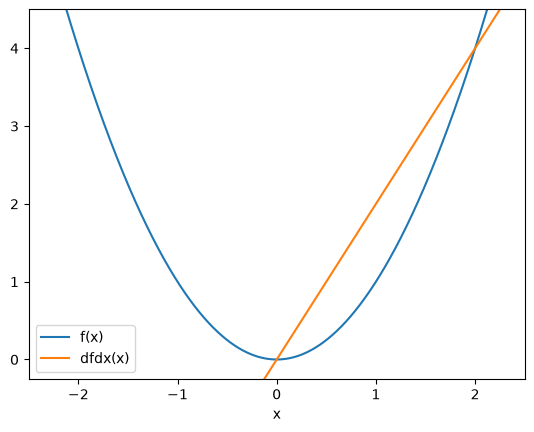

In [8]:
# visualize
plt.plot(x, f(x), label="f(x)")
plt.plot(x, dfdx_vals, label="dfdx(x)")
plt.xlim(-2.5, 2.5)
plt.ylim(-0.25, 4.5)
plt.xlabel("x")
plt.legend();

#### Computing _k-th_ derivatives with _jax.grad_ (no batch input) 

Recall that its 2nd and 3rd derivatives are $f''(x) = 1$ and $f'''(x) = 0$

In [9]:
# define 2nd and 3rd derivatives of the function f
d2fdx2 = jax.grad(dfdx)
d3fdx3 = jax.grad(d2fdx2)

In [10]:
# initialize input
x = jax.random.normal(key)

# check
jnp.isclose(d2fdx2(x), 2.), jnp.isclose(d3fdx3(x), 0.)

(Array(True, dtype=bool), Array(True, dtype=bool))

#### Computing _k-th_ derivatives with _grad_ (with batch input) 

In [11]:
# vectorize 2nd and 3rd derivative function to allow a batch input
d2fdx2_batch = jax.vmap(d2fdx2)
d3fdx3_batch = jax.vmap(d3fdx3)

In [12]:
# generate data
batch_size = int(1e5)
x = jnp.linspace(-3, 3, batch_size)

# evaluate 2nd and 3rd derivative
d2fdx2_vals = d2fdx2_batch(x)
d3fdx3_vals = d3fdx3_batch(x)

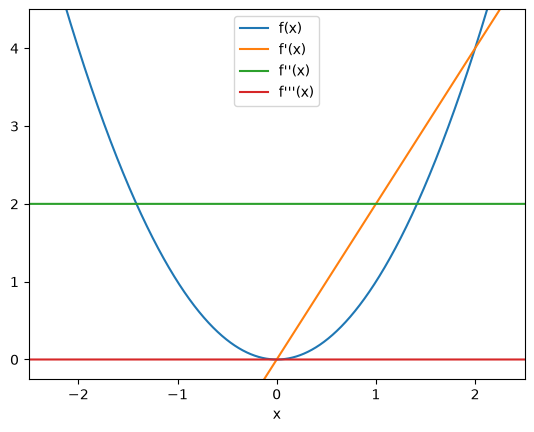

In [13]:
# visualize
plt.plot(x, f(x), label="f(x)")
plt.plot(x, dfdx_vals, label="f'(x)")
plt.plot(x, d2fdx2_vals, label=r"f''(x)")
plt.plot(x, d3fdx3_vals, label="f'''(x)")
plt.xlim(-2.5, 2.5)
plt.ylim(-0.25, 4.5)
plt.xlabel("x")
plt.legend();